   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

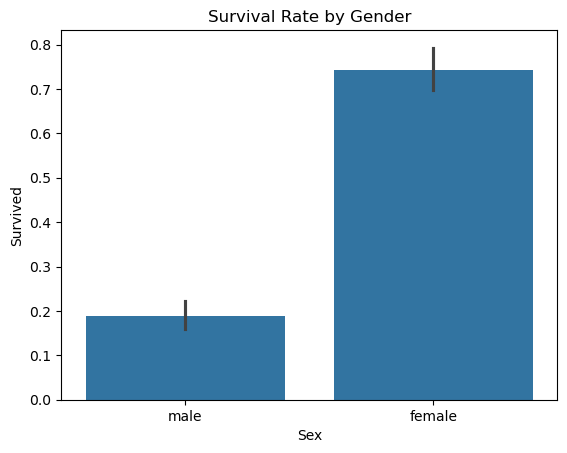

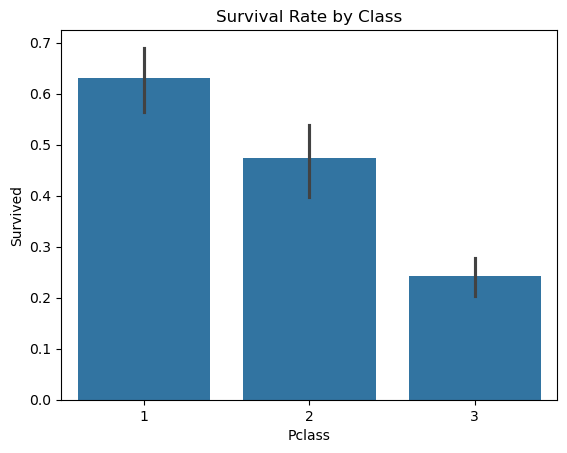

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('train.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()


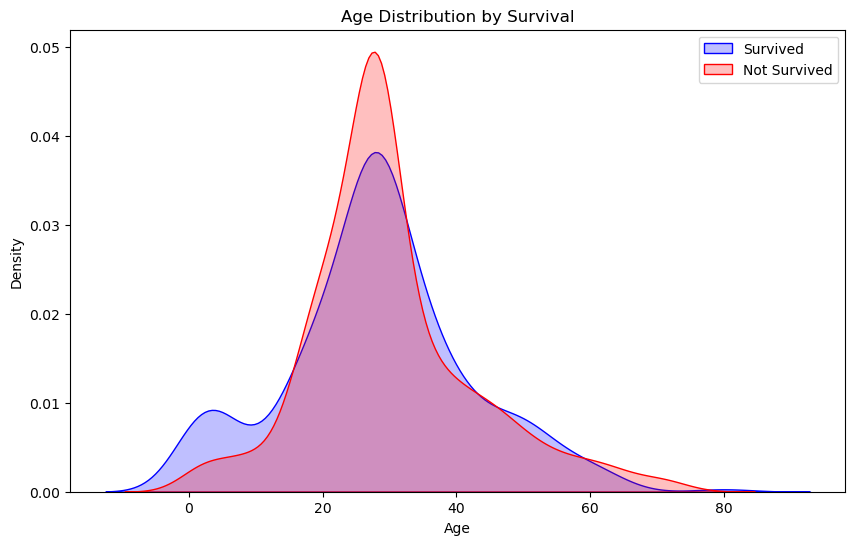

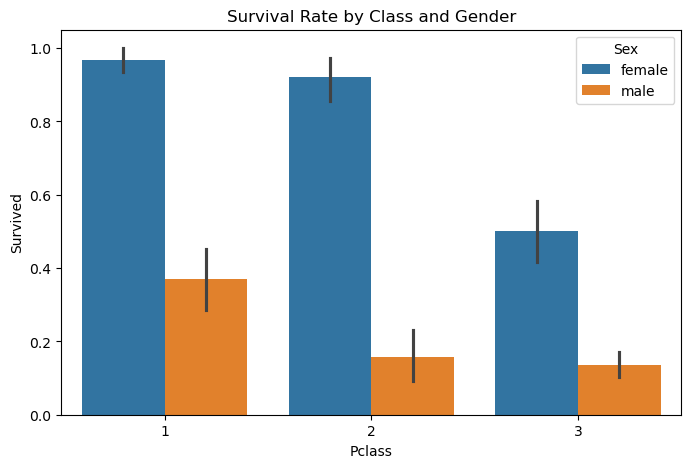


Final Model Accuracy: 81.01%


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Dataset Loading & Cleaning
df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin'], inplace=True, errors='ignore') # Cabin-la rōmba missing values irukkum

# 2. Visualizations
# Age Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Survived'] == 1]['Age'], fill=True, color="blue", label="Survived")
sns.kdeplot(df[df['Survived'] == 0]['Age'], fill=True, color="red", label="Not Survived")
plt.title('Age Distribution by Survival')
plt.legend()
plt.show()

# Survival by Class & Gender
plt.figure(figsize=(8, 5))
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.title('Survival Rate by Class and Gender')
plt.show()

# 3. Feature Engineering (Categorical to Numerical)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 4. Machine Learning - Logistic Regression
# Unnecessary columns-ah drop pannuvom
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'], errors='ignore')
y = df['Survived']

# Data-va Train & Test-aa pirikkalaam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy Check
y_pred = model.predict(X_test)
print(f"\nFinal Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")